# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [2]:
def classify_number(n):
    if n < 0:
        return "negative"
    elif n == 0:
        return "zero"
    elif n <= 10:
        return "small positive"
    else:
        return "large positive"

# Tests
assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [3]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

# 1. word_count dict
word_count = {}
for w in words:
    if w in word_count:
        word_count[w] += 1
    else:
        word_count[w] = 1

# 2. unique_words set
unique_words = set(words)  # YOUR CODE HERE

# 3. long_words list comprehension
long_words = [w for w in words if len(w) > 5]

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [4]:
def safe_divide(a, b):
    if not isinstance(a, (int, float)) or not isinstance(b, (int, float)):
        raise TypeError("Inputs must be numeric")
    try:
        return a / b
    except ZeroDivisionError:
        return None
# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None
try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"
except TypeError as e:
    assert str(e) == "Inputs must be numeric"
print("1.3 passed ✓")

1.3 passed ✓


### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [5]:
def apply_twice(f, x):
      return f(f(x))

triple = lambda x: x * 3


result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [6]:
import numpy as np

arr1d = np.arange(12)
arr2d = arr1d.reshape(3, 4)
arr3d = arr1d.reshape(2, 2, 3)

print(f"arr1d — shape: {arr1d.shape}, ndim: {arr1d.ndim}, dtype: {arr1d.dtype}")
print(f"arr2d — shape: {arr2d.shape}, ndim: {arr2d.ndim}, dtype: {arr2d.dtype}")
print(f"arr3d — shape: {arr3d.shape}, ndim: {arr3d.ndim}, dtype: {arr3d.dtype}")

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

arr1d — shape: (12,), ndim: 1, dtype: int64
arr2d — shape: (3, 4), ndim: 2, dtype: int64
arr3d — shape: (2, 2, 3), ndim: 3, dtype: int64
2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [7]:
row2 = arr2d[1]          # second row (0-indexed)
column3 = arr2d[:, 2]       # third column
sub  = arr2d[1:, 2:]     # bottom-right 2x2
gt7  = arr2d[arr2d > 7]  # boolean indexing

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(column3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [8]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C  = A * B                          # element-wise
D  = A @ B                          # matrix multiplication
dp = np.dot(np.array([1,2,3]), np.array([4,5,6]))  # dot product
E  = A * 3                          # scalar multiplication

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓


---
## Part 3 — Pandas

In [9]:
import pandas as pd
from io import StringIO

# Load dataset — do not modify this cell
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [10]:
salary_series = df['salary']
name_dept_df  = df[['name', 'department']]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [11]:
iloc_result = df.iloc[2:5 , 0:3]
loc_result  = df.loc[5:6, ['name', 'salary']]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)

3.2 passed ✓


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


,name,salary
5,Frank,68000.0
6,Grace,NaN


### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [12]:
senior_eng = df[(df['department'] == 'Engineering') & (df['salary'] > 90000)]

dept_stats = (
    df.groupby('department')
    .agg(mean_salary=('salary', 'mean'), mean_performance=('performance', 'mean'))
    .sort_values('mean_salary', ascending=False)
)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,mean_salary,mean_performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


### 3.4 Handling Missing Data

1. Identify which columns have missing values and how many → print a summary.
2. Fill missing `salary` with the **median salary** → `df_filled`
3. Fill missing `age` with the **mean age** (rounded to nearest int).
4. Drop rows where `performance` is missing.
5. Confirm no nulls remain.

In [13]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()
# Fill missing salary with median
median_salary = df_filled['salary'].median()
df_filled['salary'] = df_filled['salary'].fillna(median_salary)

# Fill missing age with mean (rounded)
mean_age = round(df_filled['age'].mean())
df_filled['age'] = df_filled['age'].fillna(mean_age)

# Drop rows where performance is missing
df_filled = df_filled.dropna(subset=['performance'])

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

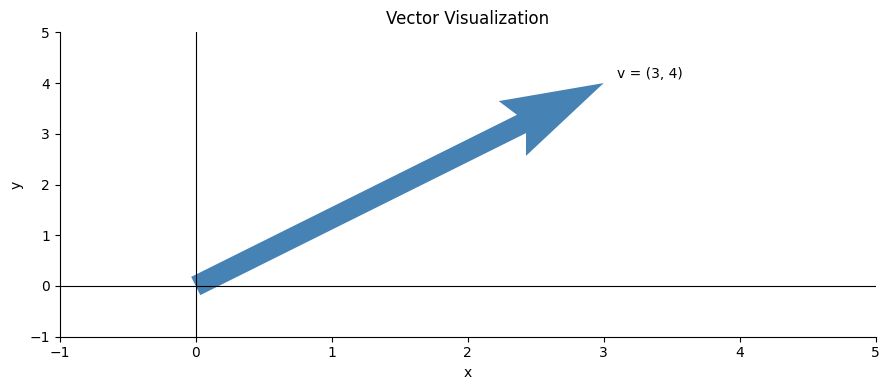

<Figure size 900x400 with 0 Axes>

4.1 passed ✓  |v| = 5.0


In [14]:
from matplotlib import pyplot as plt

v = np.array([3, 4])
norm_v = np.linalg.norm(v)

M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

# Plot
fig, ax = plt.subplots()
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='steelblue', width=0.025)
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.text(v[0] + 0.1, v[1] + 0.1, f'v = (3, 4)', fontsize=10)
plt.tight_layout(); plt.show()

ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [15]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

PplusQ   = P + Q
scalar3P = 3 * P
PQ       = P @ Q
QP       = Q @ P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

**Meaning of "Streatching a Vector"**

Eigenvectors are special vectors whose direction remains unchanged after a matrix transformation. Eigenvalues indicate how much those vectors are stretched, compressed, or reversed. Geometrically, a matrix can change the size and orientation of vectors, but eigenvectors point in directions that only change in magnitude and not in direction.

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Eigenpair 1: λ = 5.0000
  A @ v  = [3.53553391 3.53553391]
  λ * v  = [3.53553391 3.53553391]
  Match? True

Eigenpair 2: λ = 2.0000
  A @ v  = [-0.89442719  1.78885438]
  λ * v  = [-0.89442719  1.78885438]
  Match? True


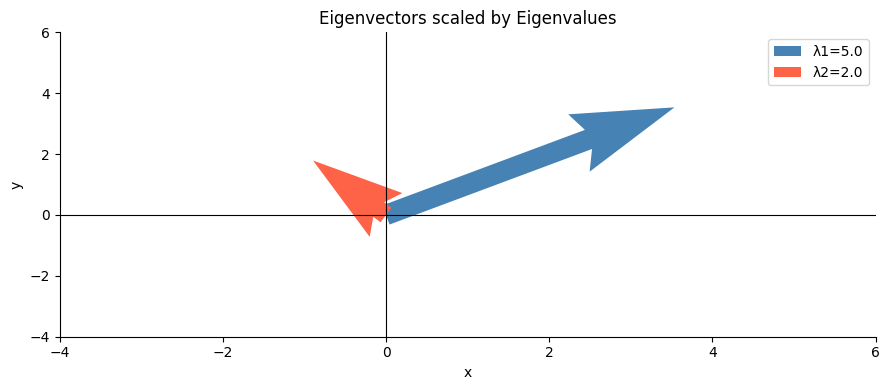

4.3 passed ✓


In [16]:
A = np.array([[4, 1], [2, 3]], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors (columns):\n{eigenvectors}")

# Verify Av = λv for each eigenpair
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    vec = eigenvectors[:, i]
    lhs = A @ vec
    rhs = lam * vec
    print(f"\nEigenpair {i+1}: λ = {lam:.4f}")
    print(f"  A @ v  = {lhs}")
    print(f"  λ * v  = {rhs}")
    print(f"  Match? {np.allclose(lhs, rhs)}")

# Plot eigenvectors scaled by eigenvalues
fig, ax = plt.subplots()
colors = ['steelblue', 'tomato']
for i in range(len(eigenvalues)):
    vec = eigenvectors[:, i] * eigenvalues[i]
    ax.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1,
              color=colors[i], width=0.025, label=f'λ{i+1}={eigenvalues[i]:.1f}')

ax.set_xlim(-4, 6); ax.set_ylim(-4, 6)
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Eigenvectors scaled by Eigenvalues')
ax.legend()
plt.tight_layout(); plt.show()

print("4.3 passed ✓")

**Your Geometric Explanation (4.3):**

> Eigenvectors are special vectors whose direction remains unchanged when a matrix transformation is applied. The corresponding eigenvalue tells us how much the vector is stretched, compressed, or reversed along that direction. Geometrically, a matrix can rotate, stretch, or squish vectors, but eigenvectors represent the directions that are only scaled and not turned. If the eigenvalue is greater than 1, the vector is stretched; if it is between 0 and 1, the vector is compressed; and if it is negative, the vector is flipped in the opposite direction.


### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In [17]:
np.random.seed(42)
X = np.random.randn(4, 3)

U, S, Vt = np.linalg.svd(X, full_matrices=False)

# Reconstruct X from SVD: U @ diag(S) @ Vt
X_reconstructed = U @ np.diag(S) @ Vt

# Rank-1 approximation: only the largest singular value
X_approx = S[0] * np.outer(U[:, 0], Vt[0, :])

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [2.37642759 0.91384752 0.81326001]
Reconstruction error: 8.01e-16
Rank-1 approximation:
[[ 0.31621043  0.03811706 -0.07014701]
 [ 1.45405951  0.17527718 -0.32256347]
 [ 1.66945396  0.20124154 -0.37034582]
 [ 0.55465885  0.06686043 -0.12304358]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

>Singular Value Decomposition (SVD) and Principal Component Analysis (PCA) are closely related techniques for dimensionality reduction. In SVD, a data matrix is decomposed into U, S, and Vᵀ, where the columns of V represent the principal directions of the data. PCA uses these directions as principal components, and the singular values in S indicate how much variance each component captures. Larger singular values correspond to more important principal components, allowing us to reduce dimensions while preserving most of the information in the dataset.


---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


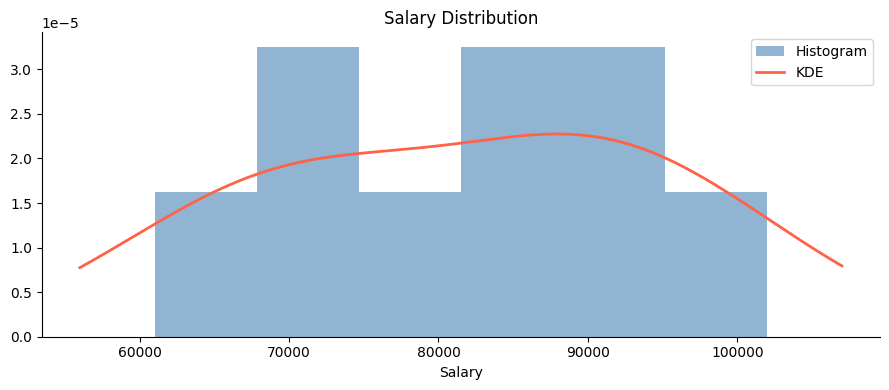

In [18]:
import scipy.stats as stats

salary = df_filled['salary']

mean_s   = salary.mean()
median_s = salary.median()
std_s    = salary.std()
min_s    = salary.min()
max_s    = salary.max()
iqr_s    = np.percentile(salary, 75) - np.percentile(salary, 25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram + KDE
fig, ax = plt.subplots()
ax.hist(salary, bins=6, color='steelblue', alpha=0.6, density=True, label='Histogram')
kde_x = np.linspace(salary.min() - 5000, salary.max() + 5000, 300)
kde = stats.gaussian_kde(salary)
ax.plot(kde_x, kde(kde_x), color='tomato', lw=2, label='KDE')
ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
ax.legend()
plt.tight_layout(); plt.show()

**Definitions (5.1):**

- **Population:** A population is the complete set of individuals, objects, or observations that we want to study.

- **Sample:** A sample is a subset of the population that is selected for analysis.

- **Descriptive statistic:** A descriptive statistic summarizes and describes the main characteristics of a dataset, such as its mean or standard deviation.

- **Inferential statistic:** An inferential statistic uses sample data to draw conclusions or make predictions about a larger population.

### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

In [19]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

# One-sample t-test
t_stat, p_value = stats.ttest_1samp(eng_salaries, overall_mean)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 at α=0.05? {p_value < 0.05}")

# Pearson correlation
r, r_pval = stats.pearsonr(df_filled['salary'], df_filled['years_exp'])
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


**H₀ / H₁ and Interpretation (5.2):**

- H₀: The mean salary of employees in the Engineering department is equal to the overall mean salary.

- H₁: The mean salary of employees in the Engineering department is different from the overall mean salary.

- Conclusion: The p-value (0.0280) is less than the significance level of 0.05, so we reject the null hypothesis. There is sufficient statistical evidence to conclude that the mean salary of employees in the Engineering department differs significantly from the overall mean salary.

### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [20]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2

mae    = np.mean(np.abs(y_true - y_pred))
mse    = np.mean((y_true - y_pred) ** 2)
rmse   = np.sqrt(mse)
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2     = 1 - (ss_res / ss_tot)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [21]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)
s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

# KS test — compare each against N(0,1)
ks_s1 = stats.kstest(s1, 'norm', args=(0, 1))
ks_s2 = stats.kstest(s2, 'norm', args=(0, 1))
print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

# ADF test on non-stationary series
t = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result =  adfuller(ts)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

# Difference once and re-run
ts_diff  = np.diff(ts)
adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

PSI: 2.0611
Shift severity: Major


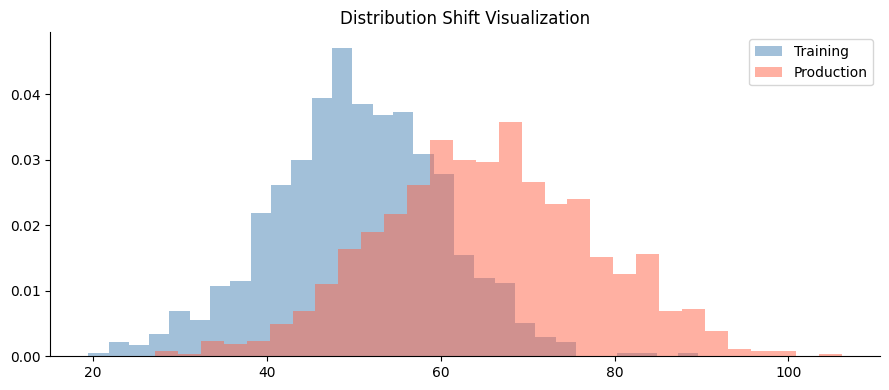

In [22]:
def compute_psi(expected, actual, bins=10):
    eps = 1e-10
    # Build bin edges from the expected distribution
    breakpoints = np.linspace(expected.min(), expected.max(), bins + 1)

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts   = np.histogram(actual,   bins=breakpoints)[0]

    expected_pct = expected_counts / len(expected) + eps
    actual_pct   = actual_counts   / len(actual)   + eps

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)
drift_dist = np.random.normal(65, 12, 1000)

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

# Plot both distributions
fig, ax = plt.subplots()
ax.hist(train_dist, bins=30, alpha=0.5, color='steelblue', density=True, label='Training')
ax.hist(drift_dist, bins=30, alpha=0.5, color='tomato',    density=True, label='Production')
ax.legend(); ax.set_title('Distribution Shift Visualization')
plt.tight_layout(); plt.show()

**Concept Drift vs Covariate Drift & PSI Thresholds (5.5):**

- **Concept drift:** Concept drift occurs when the relationship between input features and the target variable changes over time, causing the model's predictions to become less accurate.

- **Covariate drift:** Covariate drift occurs when the distribution of input features changes over time, even if the relationship between the features and the target remains the same.

- **PSI < 0.1:** No significant shift; the feature distribution is considered stable.

- **PSI 0.1–0.2:** Minor or moderate shift; the feature should be monitored for potential changes.

- **PSI > 0.2:** Major shift; the feature distribution has changed significantly and may impact model performance.

- **Retraining trigger example:** Retraining can be triggered when a feature's PSI exceeds 0.2 or when model performance metrics such as accuracy, precision, or recall drop below an acceptable threshold.

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [23]:
total = 10
red, blue, green = 4, 3, 3

p_red = red / total
p_blue = blue / total
p_green = green / total

# Joint: P(red first AND blue second)
p_red_then_blue = (red / total) * (blue / (total - 1))

# Conditional: P(blue second | red first)
p_blue_given_red = blue / (total - 1)

# Independence check: are P(B|A) == P(B) ?
independent = abs(p_blue_given_red - p_blue) < 1e-9

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

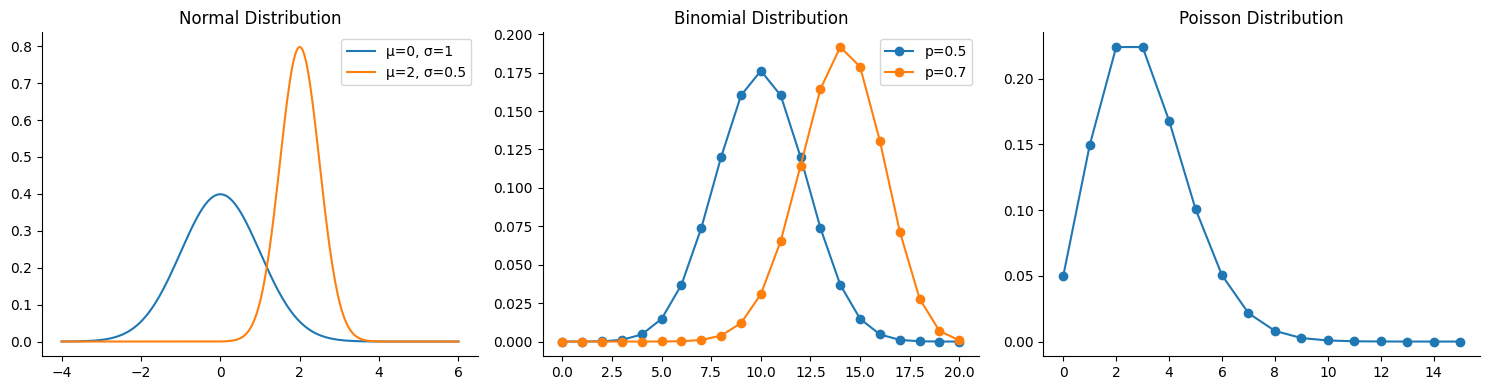

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Normal ──────────────────────────────────────────────────────────────────
x = np.linspace(-4, 6, 300)
pdf1 = stats.norm.pdf(x, loc=0, scale=1)
pmf2 = stats.norm.pdf(x, loc=2, scale=0.5)

axes[0].plot(x, pdf1, label='μ=0, σ=1')
axes[0].plot(x, pmf2, label='μ=2, σ=0.5')
axes[0].legend()
# ML use case:
# Used in Gaussian assumptions, feature distributions,
# and many statistical learning methods.
axes[0].set_title('Normal Distribution')

# ── Binomial ────────────────────────────────────────────────────────────────
k = np.arange(0, 21)

pmf1 = stats.binom.pmf(k, 20, 0.5)
pmf2 = stats.binom.pmf(k, 20, 0.7)

axes[1].plot(k, pmf1, marker='o', label='p=0.5')
axes[1].plot(k, pmf2, marker='o', label='p=0.7')
axes[1].legend()

# ML use case:
# Modeling binary outcomes such as clicks,
# purchases, or classification successes.
axes[1].set_title('Binomial Distribution')

# ── Poisson ─────────────────────────────────────────────────────────────────
k2 = np.arange(0, 16)

poisson_pmf = stats.poisson.pmf(k2, mu=3)

axes[2].plot(k2, poisson_pmf, marker='o')

# ML use case:
# Event counts such as arrivals, requests,
# failures, or anomalies per time interval.
axes[2].set_title('Poisson Distribution')

plt.tight_layout();
plt.show()

### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

In [25]:
p_spam            = 0.30
p_free_given_spam = 0.80
p_free_given_ham  = 0.05
p_ham             = 1 - p_spam

# P(free) — law of total probability
p_free = (  p_free_given_spam * p_spam
    + p_free_given_ham * p_ham
)

# Bayes
p_spam_given_free = (
    p_free_given_spam * p_spam
) / p_free

print(f"P('free'): {p_free:.4f}")
print(f"P(Spam | 'free'): {p_spam_given_free:.4f}")

def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    p_ham = 1 - prior_spam

    p_word = (
        p_word_given_spam * prior_spam
        + p_word_given_ham * p_ham
    )

    return (p_word_given_spam * prior_spam) / p_word


pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - p_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


### Bayes Term Mapping (6.3)

| Term       | Formula        | In this example                                                            |
| ---------- | -------------- | -------------------------------------------------------------------------- |
| Prior      | P(Spam)        | Probability that an email is spam before seeing the word "free" (0.30)     |
| Likelihood | P(word | Spam) | Probability of seeing the word "free" given that the email is spam (0.80)  |
| Evidence   | P(word)        | Overall probability of seeing the word "free" in any email (0.275)         |
| Posterior  | P(Spam | word) | Probability that an email is spam after observing the word "free" (0.8727) |
|            |                |                                                                            |


### 6.4 Central Limit Theorem

1. Define a population following an **exponential distribution** (λ=1, size=100,000).
2. Repeatedly draw samples of size `n=30` and record their means — do this 5,000 times.
3. Plot the histogram of sample means.
4. Overlay the **theoretical normal distribution** predicted by the CLT: μ = population mean, σ = population_std / sqrt(n).
5. Run a KS test to confirm the distribution of sample means is approximately normal.

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 0.9971, std: 0.1828
CLT predicted std: 0.1827


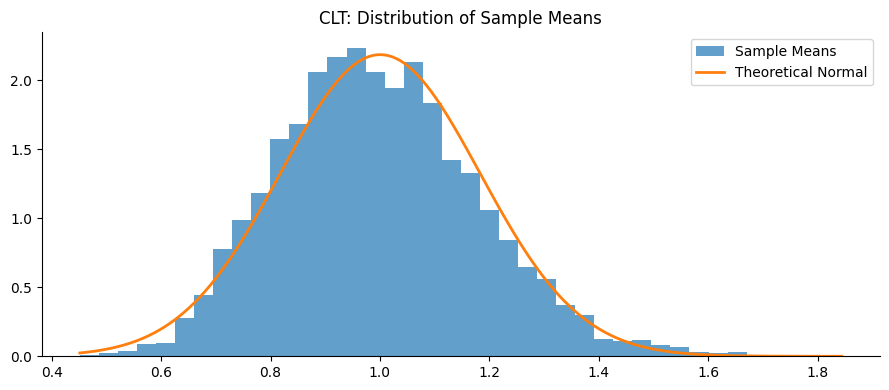

KS test p-value: 0.0000 → Approximately normal? False


In [26]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

n_samples = 5000
sample_size = 30
sample_means = np.array([
    np.random.choice(population, size=sample_size).mean()
    for _ in range(n_samples)
])

pop_mean = population.mean()
pop_std  = population.std()
clt_std  = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot
fig, ax = plt.subplots()
ax.hist(
    sample_means,
    bins=40,
    density=True,
    alpha=0.7,
    label='Sample Means'
)

x = np.linspace(
    sample_means.min(),
    sample_means.max(),
    300
)

ax.plot(
    x,
    stats.norm.pdf(x, pop_mean, clt_std),
    linewidth=2,
    label='Theoretical Normal'
)

ax.legend()
ax.set_title('CLT: Distribution of Sample Means')
plt.tight_layout(); plt.show()

# KS test
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

**CLT Reflection (6.4):**

The Central Limit Theorem is important because it shows that the distribution of sample means approaches a normal distribution as sample size increases, even when the original data is not normally distributed. This allows many statistical methods and machine learning techniques to rely on normal-distribution approximations. The CLT justifies the normality assumption used in classical hypothesis tests, confidence intervals, and parameter estimation.


---
## 🏁 Submission Checklist

Before submitting, verify:

- [ ] All `assert` blocks pass without errors
- [ ] All `# YOUR CODE HERE` cells are filled
- [ ] All markdown reflection cells are filled in your own words
- [ ] All plots render with labels and titles
- [ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`